### Permutation importance
- Model-agnostic method
- Assesses feature importance
    - Measures effect of feature shuffling on performance
- Highly versatile 


In [2]:
import pandas as pd

admission = pd.read_csv('admission_data.csv')
admission

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Chance of Admit,Accept
0,337,118,4,4.5,4.5,9.65,0.92,1
1,324,107,4,4.0,4.5,8.87,0.76,1
2,316,104,3,3.0,3.5,8.00,0.72,1
3,322,110,3,3.5,2.5,8.67,0.80,1
4,314,103,2,2.0,3.0,8.21,0.65,0
...,...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,0.87,1
496,337,117,5,5.0,5.0,9.87,0.96,1
497,330,120,5,4.5,5.0,9.56,0.93,1
498,312,103,4,4.0,5.0,8.43,0.73,1


In [3]:
X = admission.drop('Accept', axis=1).fillna(admission.mean())
y = admission['Accept']

In [4]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(3)
memory usage: 27.5 KB


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

#### MLPClassifier

In [6]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(hidden_layer_sizes=(10,10))
model.fit(X_train, y_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(10, 10))

### Permutation importance

In [7]:
from sklearn.inspection import permutation_importance
result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=42, scoring='accuracy')
print(result.importances_mean)

[ 0.00475  0.027    0.07325  0.0005  -0.014   -0.0945  -0.00025]


#### Visualizing importance


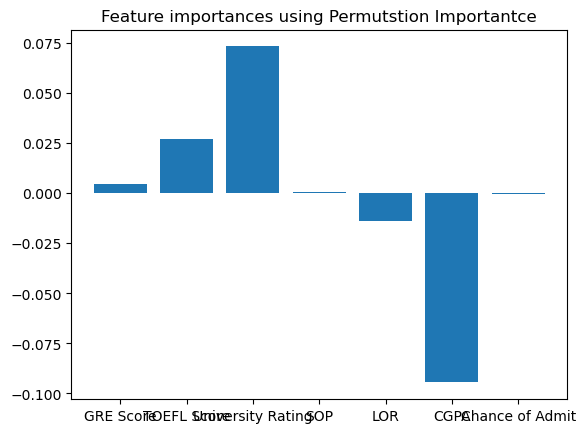

In [11]:
import matplotlib.pyplot as plt
plt.bar(X_train.columns, result.importances_mean)
plt.title("Feature importances using Permutstion Importantce")
plt.show()

In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance

model = MLPClassifier(hidden_layer_sizes=(10), random_state=1)
model.fit(X, y)

MLPClassifier(hidden_layer_sizes=10, random_state=1)

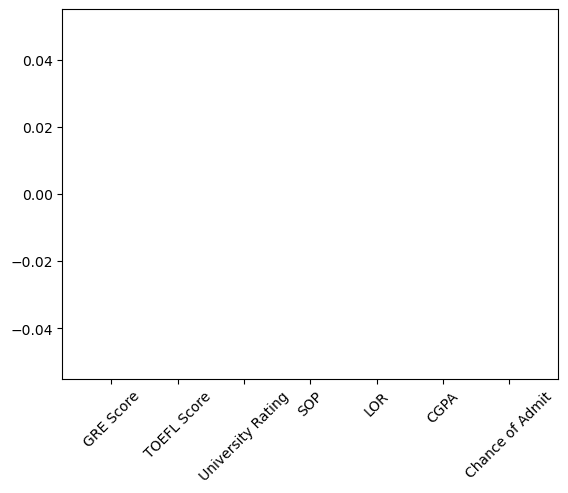

In [17]:
# Compute the permutation importance
result = permutation_importance(model, X, y, n_repeats=10, random_state=1 )

# Plot feature importances
plt.bar(X.columns, result.importances_mean)
plt.xticks(rotation=45)
plt.show()

In [19]:
import numpy as np
def plot_importances(coefficients,  perm_importances):
    features = X.columns  

    x = np.arange(len(features))  # the label locations
    width = 0.35  # the width of the bars

    fig, ax1 = plt.subplots()

    # Plotting coefficients on the primary y-axis
    rects1 = ax1.bar(x - width/2, np.abs(coefficients), width, label='Coefficients', color='b')
    ax1.set_ylabel('Coefficient Magnitude', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_xticks(x)
    ax1.set_xticklabels(features, rotation=45)
    
    # Creating a secondary y-axis for permutation importances
    ax2 = ax1.twinx()
    rects2 = ax2.bar(x + width/2, perm_importances, width, label='Permutation Importance', color='g')
    ax2.set_ylabel('Permutation Importance', color='g')
    ax2.tick_params(axis='y', labelcolor='g')

    # Adding title and adjusting layout
    ax1.set_title('Logistic Regression Coefficients vs. Permutation Importance')
    fig.tight_layout()

    # Adding legends outside the plot
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    # Placing the legend to the right outside of the plot
    ax1.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(2, 1), borderaxespad=0.)

    # Adjusting the layout to avoid overlap
    plt.subplots_adjust(right=0.8)  # Allows space for the legend on the right

    plt.show()

In [20]:
from sklearn.inspection import permutation_importance

# Extract and store model coefficients
coefficients = model.coef_[0]

# Compute permutation importance on the test set
perm_importance = permutation_importance(model, X, y, n_repeats=20, random_state=1)


# Compute the average permutation importance
avg_perm_importance = perm_importance.importances_mean

plot_importances(coefficients, avg_perm_importance)

AttributeError: 'MLPClassifier' object has no attribute 'coef_'

###  SHAP explainability
Deriving SHAP values

In [22]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 2.3 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- -------------

In [24]:
import shap

In [ ]:
# Regression
explainer_reg = shap.TreeExplainer(rf_reg)
shap_values_reg = explainer_reg.shap_values(X)

In [ ]:
# Classification
explainer_class = shap.TreeExplainer(rf_class)
shap_values_class = explainer_class.shap_values(X)

In [ ]:
# Regression shape
print(shap_values_reg.shape)

In [ ]:
# Classification shape
print(shap_values_class.shape)

select values of positive class

In [ ]:
positive_values = np.abs(shap_values_class[:, :, 1])


Feature importance

In [ ]:
mean_shap_values_class = np.abs(shap_values_class[:,:, 1].mean(axis=0))
mean_shap_values_reg = np.abs(shap_values_reg).mean(axis=0)
plt.bar(X_train.columns, mean_shap_values_class)
plt.bar(X_train.columns, mean_shap_values_reg)

Select values of positive class

In [ ]:
positive_values = shap_values_class[:,:, 1]

### Exercise:
- Finding key medical charge predictors with SHAP

In [ ]:
import shap

# Create a SHAP Tree Explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X)

# Calculate mean absolute SHAP values
mean_abs_shap = np.abs(shap_values).mean(axis=0)

plt.bar(X.columns, mean_abs_shap)
plt.title('Mean Absolute SHAP Values for RandomForest')
plt.xticks(rotation=45)
plt.show()

- Finding key heart disease predictors with SHAP

In [ ]:
import shap

# Create a SHAP Tree Explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X)

# Calculate mean absolute SHAP values
mean_abs_shap = np.abs(shap_values[:, : , 1]).mean(axis=0)

plt.bar(X.columns, mean_abs_shap)
plt.title('Mean Absolute SHAP Values for RandomForest')
plt.xticks(rotation=45)
plt.show()

### SHAP kernel explainer

In [ ]:
heart_df = pd.read_csv("heart.csv")
heart_df.head()